<a href="https://colab.research.google.com/github/asternoeld/avcad/blob/main/exercise10_LDA/exercise10_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Analysis and Visualization of Complex Agro-Environmental Data
### Exercise 10 – Linear Discriminant Analysis


Linear Discriminant Analysis (LDA) of the EFIplus Mediterranean dataset, using quantitative environmental variables to discriminate four river basins (Douro, Tejo, Mondego and Minho). The preprocessing follows the previous exercises; the analysis ends with a static biplot and interactive plots in the discriminant-function space.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import confusion_matrix

import plotly.express as px
import plotly.io as pio

sns.set(style="whitegrid")
pio.renderers.default = "colab"

### 1. Data loading and preprocessing

In [15]:
# ---- load data ----
url = "https://raw.githubusercontent.com/asternoeld/avcad/main/exercise10_LDA/EFIplus_medit.zip"
df = pd.read_csv(url, compression="zip", sep=";")
df.columns = list(map(str, df.columns))

# ---- keep the four target basins ----
basins = ["Douro", "Tejo", "Mondego", "Minho"]
df_sub = df[df["Catchment_name"].isin(basins)].copy()

# ---- quantitative environmental variables (same set as the previous exercises) ----
env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul",
]

# drop sites with missing values in any of these variables
df_env = df_sub[["Catchment_name"] + env_vars].dropna().copy()

# standardize the predictors before the analysis
scaler = StandardScaler()
X = scaler.fit_transform(df_env[env_vars].values)
X_df = pd.DataFrame(X, columns=env_vars, index=df_env.index)

groups = df_env["Catchment_name"]
df_env["Catchment_name"].value_counts()

,count
Catchment_name,
Minho,707
Tejo,493
Douro,395
Mondego,86


After dropping incomplete records, 1681 sites remain. The groups are unbalanced: Minho (707) and Tejo (493) dominate, Douro has 395 sites and Mondego is the smallest with 86.

### 2. Linear Discriminant Analysis

In [16]:
# encode the basin labels
le = LabelEncoder()
y = le.fit_transform(groups)

# fit LDA: four groups give three discriminant functions
lda = LDA(n_components=3)
lda_scores = lda.fit_transform(X_df.values, y)

lda_scores_df = pd.DataFrame(lda_scores, columns=["LD1", "LD2", "LD3"], index=X_df.index)
lda_scores_df["Catchment_name"] = groups.values
lda_scores_df.head()

,LD1,LD2,LD3,Catchment_name
1,0.760907,1.286815,0.392985,Tejo
2,1.253890,0.970456,-0.065964,Tejo
3,0.356260,1.209093,0.037449,Tejo
4,0.397627,1.015236,0.907298,Tejo
5,0.442558,1.211482,0.377666,Tejo


#### Explained discriminant variance

In [17]:
evr = lda.explained_variance_ratio_
evr_df = pd.DataFrame({
    "Explained variance (%)": np.round(evr * 100, 2),
    "Cumulative (%)": np.round(np.cumsum(evr) * 100, 2),
}, index=["LD1", "LD2", "LD3"])
evr_df

,Explained variance (%),Cumulative (%)
LD1,90.62,90.62
LD2,5.73,96.35
LD3,3.65,100.00


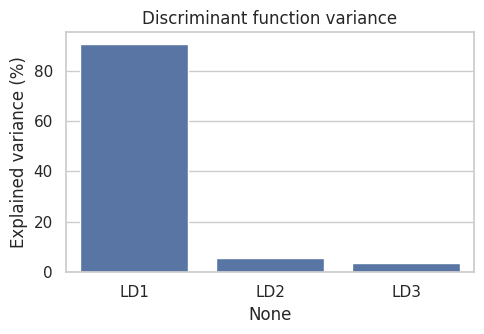

In [18]:
plt.figure(figsize=(5, 3.5))
sns.barplot(x=evr_df.index, y=evr * 100, color="#4c72b0")
plt.ylabel("Explained variance (%)")
plt.title("Discriminant function variance")
plt.tight_layout()
plt.show()

LD1 captures about 91% of the between-basin variance, so the separation between catchments is essentially one-dimensional. LD2 and LD3 add little (roughly 6% and 4%).

#### Discriminant loadings

In [19]:
lda_loadings = pd.DataFrame(lda.scalings_[:, :3], index=env_vars,
                            columns=["LD1", "LD2", "LD3"])
lda_loadings.round(3)

,LD1,LD2,LD3
Altitude,3.573,-0.669,-0.845
Actual_river_slope,0.101,-0.186,0.181
Elevation_mean_catch,0.270,-1.658,0.693
prec_ann_catch,-0.490,-0.094,-1.019
temp_ann,3.091,-1.180,-6.113
temp_jan,1.226,-2.281,4.654
temp_jul,0.472,1.014,1.668


Altitude and mean annual temperature carry the largest weights on LD1, with January temperature also contributing, so LD1 is an elevation/temperature gradient. LD2 is driven mainly by January temperature and mean catchment elevation.

### 3. Model performance

Cross-validated accuracy: 0.835 (+/- 0.023)


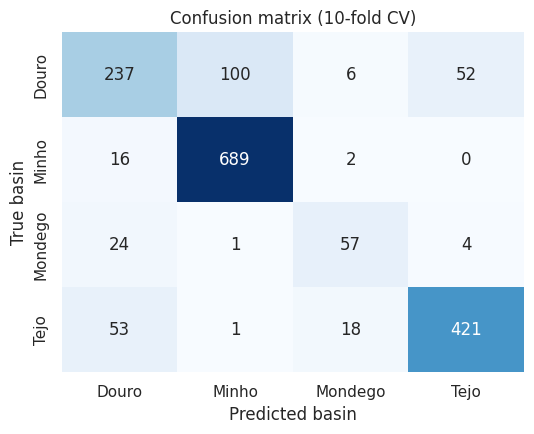

In [20]:
# repeated stratified k-fold cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
cv_scores = cross_val_score(lda, X_df.values, y, scoring="accuracy", cv=cv, n_jobs=-1)
print(f"Cross-validated accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# confusion matrix from cross-validated predictions
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
y_pred = cross_val_predict(lda, X_df.values, y, cv=skf)
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted basin")
plt.ylabel("True basin")
plt.title("Confusion matrix (10-fold CV)")
plt.tight_layout()
plt.show()

Most sites are assigned to the correct basin. Minho separates most cleanly, while Douro and Tejo overlap and account for the bulk of the misclassifications, which matches their adjacent positions along LD1.

### 4. LDA biplot

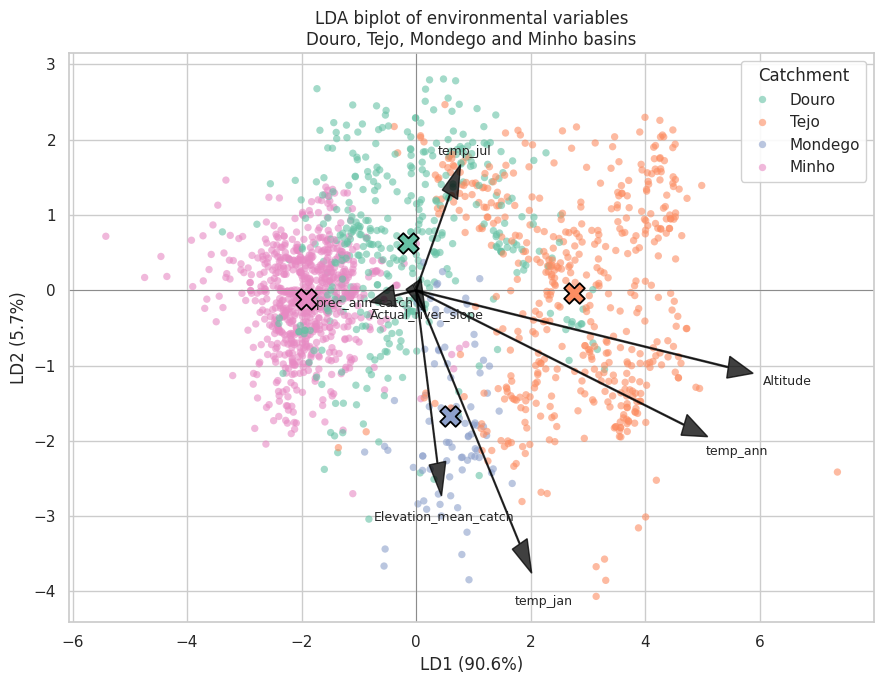

In [21]:
basin_palette = dict(zip(basins, sns.color_palette("Set2", 4)))

# scale the variable vectors to the spread of the site scores
scores2d = lda_scores_df[["LD1", "LD2"]].values
span = np.abs(scores2d).max()
arrow_scale = 0.8 * span / np.abs(lda_loadings[["LD1", "LD2"]].values).max()
head_w, line_w = 0.04 * span, 0.002 * span

plt.figure(figsize=(9, 7))
sns.scatterplot(data=lda_scores_df, x="LD1", y="LD2", hue="Catchment_name",
                hue_order=basins, palette=basin_palette, alpha=0.6, s=28,
                edgecolor="none")

# basin centroids
centroids = lda_scores_df.groupby("Catchment_name")[["LD1", "LD2"]].mean()
for b in basins:
    plt.scatter(centroids.loc[b, "LD1"], centroids.loc[b, "LD2"],
                color=basin_palette[b], s=220, marker="X",
                edgecolor="black", linewidth=1.3, zorder=5)

# environmental variable vectors
for v in env_vars:
    x = lda_loadings.loc[v, "LD1"] * arrow_scale
    y = lda_loadings.loc[v, "LD2"] * arrow_scale
    plt.arrow(0, 0, x, y, color="black", alpha=0.75, width=line_w,
              head_width=head_w, length_includes_head=True, zorder=4)
    plt.text(x * 1.10, y * 1.10, v, fontsize=9, ha="center", va="center", zorder=6)

plt.axhline(0, color="grey", lw=0.6)
plt.axvline(0, color="grey", lw=0.6)
plt.xlabel(f"LD1 ({evr[0]*100:.1f}%)")
plt.ylabel(f"LD2 ({evr[1]*100:.1f}%)")
plt.title("LDA biplot of environmental variables\nDouro, Tejo, Mondego and Minho basins")
plt.legend(title="Catchment", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

The basins spread mainly along LD1: Tejo and Minho sit at opposite ends of the altitude/temperature gradient, with Douro intermediate and overlapping both. Mondego is offset along LD2, where catchment elevation and January temperature are the relevant variables. The short vectors for slope, precipitation and July temperature indicate a weak contribution to the discrimination.

### 5. Interactive visualization in discriminant space

The plots below colour sites by basin. The legend filters groups (click to hide, double-click to isolate), and the axes support zoom and pan; hovering shows the site code and its environmental values.

In [22]:
plot_df = lda_scores_df.copy()
plot_df["Site_code"] = df.loc[plot_df.index, "Site_code"].values
for v in env_vars:
    plot_df[v] = df_env.loc[plot_df.index, v].values
plot_df.head()

,LD1,LD2,LD3,Catchment_name,Site_code,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
1,0.760907,1.286815,0.392985,Tejo,ES_02_0001,1253,13.406,1603.519424,640.327779,9.3,0.6,18.9
2,1.253890,0.970456,-0.065964,Tejo,ES_02_0002,1155,9.398,1578.678579,633.238847,10.1,1.2,19.6
3,0.356260,1.209093,0.037449,Tejo,ES_02_0003,1074,8.186,1553.219128,625.841858,10.1,1.2,19.5
4,0.397627,1.015236,0.907298,Tejo,ES_02_0004,1018,11.736,1539.684999,622.111415,10.3,1.7,20.0
5,0.442558,1.211482,0.377666,Tejo,ES_02_0005,979,2.670,1493.914010,608.146170,10.6,1.8,20.2


In [23]:
fig = px.scatter(
    plot_df, x="LD1", y="LD2", color="Catchment_name",
    category_orders={"Catchment_name": basins},
    color_discrete_sequence=px.colors.qualitative.Set2,
    hover_name="Site_code",
    hover_data={"Catchment_name": True, "LD1": ":.2f", "LD2": ":.2f",
                "Altitude": ":.0f", "temp_ann": ":.1f", "prec_ann_catch": ":.0f"},
    opacity=0.7, width=850, height=600,
    title="Interactive LDA ordination (LD1 vs LD2)",
)
fig.update_traces(marker=dict(size=6, line=dict(width=0)))
fig.update_layout(legend_title_text="Catchment")
fig.show()

In [24]:
fig3d = px.scatter_3d(
    plot_df, x="LD1", y="LD2", z="LD3", color="Catchment_name",
    category_orders={"Catchment_name": basins},
    color_discrete_sequence=px.colors.qualitative.Set2,
    hover_name="Site_code",
    hover_data={"Altitude": ":.0f", "temp_ann": ":.1f"},
    opacity=0.7, width=850, height=650,
    title="Interactive LDA ordination (LD1, LD2, LD3)",
)
fig3d.update_traces(marker=dict(size=3))
fig3d.update_layout(legend_title_text="Catchment")
fig3d.show()

Hovering makes the Douro–Tejo overlap easy to inspect at the site level, and isolating Minho in the legend shows how distinct it is on LD1. The third axis adds little: rotating the 3D view only spreads Mondego slightly along LD2–LD3, confirming that a thermal/elevation gradient explains almost all of the separation among these four basins.

## Group Members

- 29211 – Aster Noel Dsouza  
- 29400 – David Heleno Bebiano da Costa Morais